Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

In [2]:
data = df['Passengers'].values.astype(np.float32)
data

array([112., 118., 132., 129., 121., 135., 148., 148., 136., 119., 104.,
       118., 115., 126., 141., 135., 125., 149., 170., 170., 158., 133.,
       114., 140., 145., 150., 178., 163., 172., 178., 199., 199., 184.,
       162., 146., 166., 171., 180., 193., 181., 183., 218., 230., 242.,
       209., 191., 172., 194., 196., 196., 236., 235., 229., 243., 264.,
       272., 237., 211., 180., 201., 204., 188., 235., 227., 234., 264.,
       302., 293., 259., 229., 203., 229., 242., 233., 267., 269., 270.,
       315., 364., 347., 312., 274., 237., 278., 284., 277., 317., 313.,
       318., 374., 413., 405., 355., 306., 271., 306., 315., 301., 356.,
       348., 355., 422., 465., 467., 404., 347., 305., 336., 340., 318.,
       362., 348., 363., 435., 491., 505., 404., 359., 310., 337., 360.,
       342., 406., 396., 420., 472., 548., 559., 463., 407., 362., 405.,
       417., 391., 419., 461., 472., 535., 622., 606., 508., 461., 390.,
       432.], dtype=float32)

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [3]:
train_rows = int(len(data) * 0.67)
val_rows = len(data) - train_rows
print(train_rows)
print(val_rows)

96
48


In [4]:
train_data = data[0:train_rows]
val_data = data[train_rows:len(data)]

**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [5]:
import torch

In [6]:
def create_dataset (dataset, lookback):
  X_list, y_list = [], []

  for i in range(len(dataset) - lookback):

        feature = dataset[i : i + lookback]
        target = dataset[i + lookback]

        X_list.append(feature)
        y_list.append(target)

  X = torch.tensor(np.array(X_list), dtype=torch.float32)
  y = torch.tensor(np.array(y_list), dtype=torch.float32)
  y = y.reshape(y.shape[0], 1)
  return X, y

In [7]:
lookback = 1
X_train, y_train = create_dataset(train_data, lookback=lookback)
X_test, y_test = create_dataset(val_data, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [8]:
import torch.nn as nn
class AirModel(nn.Module):
    def __init__(self,  hidden_size, num_layers):
        super(AirModel, self).__init__()
        self.input_size = 1
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.batch_first = True

        self.lstm = nn.LSTM(input_size=self.input_size, hidden_size=self.hidden_size, num_layers=self.num_layers, batch_first=True)

        # Повнозвязний шар з лог софтмаксом
        self.fc = nn.Linear(in_features=self.hidden_size, out_features=1)

    def forward(self, x):
        out, _ = self.lstm(x)

        out = out[:, -1, :]
        out = self.fc(out)

        return out

In [9]:
model = AirModel(hidden_size=50, num_layers=1)
model


AirModel(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

In [10]:
test_input = torch.tensor([[[112.]]], dtype=torch.float32)
test_input

tensor([[[112.]]])

In [11]:
model.eval()
with torch.no_grad():
    prediction = model(test_input)


In [12]:
    prediction

tensor([[-0.1197]])

**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [13]:
from torch.utils.data import TensorDataset, DataLoader
train_ds = TensorDataset(X_train, y_train)
dataloader = DataLoader(train_ds, batch_size=8, shuffle=True)

In [14]:
for batch_data, batch_labels in dataloader:
    print("Batch data shape:", batch_data.shape)
    print("Batch labels shape:", batch_labels.shape)

Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([8, 1])
Batch labels shape: torch.Size([8, 1])
Batch data shape: torch.Size([7, 1])
Batch labels shape: torch.Size([7, 1])


**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [15]:
num_epochs = 2000
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
MSELoss = nn.MSELoss()

losses = []


for epoch in range(1, num_epochs + 1):
    model.train()
    epoch_loss = 0.0


    for batch_data, batch_labels in dataloader:
        inputs = batch_data.unsqueeze(1)
        preds = model(inputs)


        loss = MSELoss(preds, batch_labels)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()


    avg_epoch_loss = epoch_loss / len(dataloader)
    losses.append(avg_epoch_loss)


    if epoch % 100 == 0:
        model.eval()

        with torch.no_grad():
            train_preds = model(X_train.unsqueeze(1))
            train_mse = MSELoss(train_preds, y_train).item()
            train_rmse = np.sqrt(train_mse)


            val_preds = model(X_test.unsqueeze(1))
            val_mse = MSELoss(val_preds, y_test).item()
            val_rmse = np.sqrt(val_mse)

        print(f"Epoch {epoch} : train RMSE: {train_rmse:.4f} , test RMSE: {val_rmse:.4f}")


Epoch 100 : train RMSE: 74.0978 , test RMSE: 234.5437
Epoch 200 : train RMSE: 72.0172 , test RMSE: 225.5469
Epoch 300 : train RMSE: 71.1492 , test RMSE: 215.2137
Epoch 400 : train RMSE: 71.1492 , test RMSE: 214.9935
Epoch 500 : train RMSE: 71.1492 , test RMSE: 215.2522
Epoch 600 : train RMSE: 71.1491 , test RMSE: 215.0654
Epoch 700 : train RMSE: 71.1492 , test RMSE: 214.9804
Epoch 800 : train RMSE: 71.1491 , test RMSE: 215.1657
Epoch 900 : train RMSE: 71.1501 , test RMSE: 214.7536
Epoch 1000 : train RMSE: 71.1500 , test RMSE: 214.7640
Epoch 1100 : train RMSE: 71.1491 , test RMSE: 215.0435
Epoch 1200 : train RMSE: 71.1491 , test RMSE: 215.0942
Epoch 1300 : train RMSE: 71.1491 , test RMSE: 215.1061
Epoch 1400 : train RMSE: 71.1493 , test RMSE: 214.9606
Epoch 1500 : train RMSE: 71.1493 , test RMSE: 214.9577
Epoch 1600 : train RMSE: 71.1491 , test RMSE: 215.1274
Epoch 1700 : train RMSE: 71.1494 , test RMSE: 214.8993
Epoch 1800 : train RMSE: 71.1494 , test RMSE: 215.2904
Epoch 1900 : train 

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

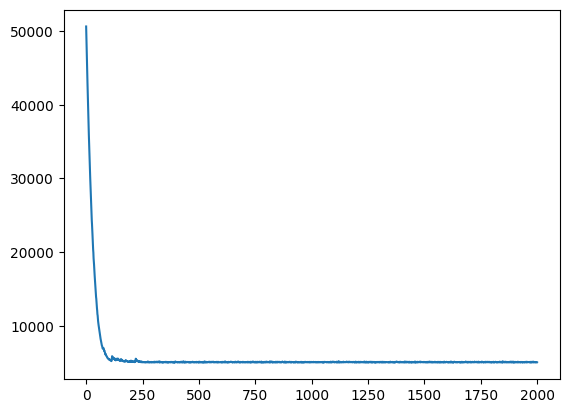

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.plot(losses);

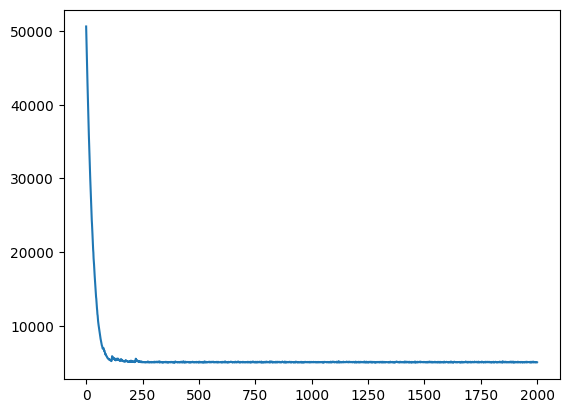

Помилка на тренувальних данних значно менша за похибку у тестувальних що вже є не дуже гарним результатом хоча і значення помилки падає між 100 та 200 епохами далі помилка не дуже змінюється.

Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

/tmp/ipykernel_7475/3250191005.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_rows] = model(X_train.unsqueeze(1))[:, -1]
/tmp/ipykernel_7475/3250191005.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_rows+lookback:len(data)] = model(X_test.unsqueeze(1))[:, -1]


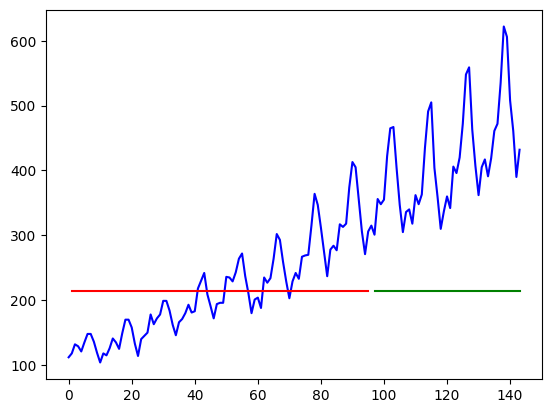

In [17]:
def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(data) * np.nan
      y_pred = model(X_train.unsqueeze(1))
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_rows] = model(X_train.unsqueeze(1))[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(data) * np.nan
      test_plot[train_rows+lookback:len(data)] = model(X_test.unsqueeze(1))[:, -1]

  # Візуалізація результатів
  plt.plot(data, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

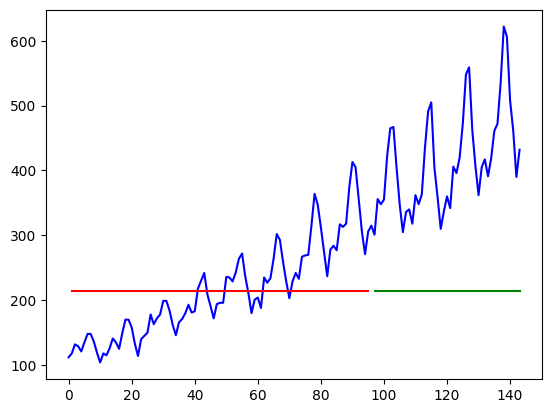

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [18]:
model_ = AirModel(hidden_size=100, num_layers=1)
print(model_)

AirModel(
  (lstm): LSTM(1, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=1, bias=True)
)


In [19]:
optimizer_ = torch.optim.Adam(model_.parameters(), lr=0.005)
MSELoss = nn.MSELoss()
losses_ = []

for epoch in range(1, num_epochs + 1):
    model_.train()
    epoch_loss = 0.0


    for batch_data, batch_labels in dataloader:
        inputs = batch_data.unsqueeze(1)
        preds = model_(inputs)


        loss = MSELoss(preds, batch_labels)


        optimizer_.zero_grad()
        loss.backward()
        optimizer_.step()

        epoch_loss += loss.item()


    avg_epoch_loss = epoch_loss / len(dataloader)
    losses_.append(avg_epoch_loss)


    if epoch % 100 == 0:
        model_.eval()

        with torch.no_grad():
            train_preds = model_(X_train.unsqueeze(1))
            train_mse = MSELoss(train_preds, y_train).item()
            train_rmse = np.sqrt(train_mse)


            val_preds = model_(X_test.unsqueeze(1))
            val_mse = MSELoss(val_preds, y_test).item()
            val_rmse = np.sqrt(val_mse)

        print(f"Epoch {epoch} : train RMSE: {train_rmse:.4f} , test RMSE: {val_rmse:.4f}")


Epoch 100 : train RMSE: 72.7956 , test RMSE: 231.4778
Epoch 200 : train RMSE: 64.4790 , test RMSE: 209.9053
Epoch 300 : train RMSE: 58.1627 , test RMSE: 202.2990
Epoch 400 : train RMSE: 52.3838 , test RMSE: 193.6897
Epoch 500 : train RMSE: 48.7391 , test RMSE: 182.6012
Epoch 600 : train RMSE: 42.1857 , test RMSE: 172.6004
Epoch 700 : train RMSE: 38.3008 , test RMSE: 163.6083
Epoch 800 : train RMSE: 35.4360 , test RMSE: 153.5663
Epoch 900 : train RMSE: 33.4119 , test RMSE: 153.2470
Epoch 1000 : train RMSE: 31.2201 , test RMSE: 140.9979
Epoch 1100 : train RMSE: 29.0549 , test RMSE: 136.8560
Epoch 1200 : train RMSE: 27.4115 , test RMSE: 129.8138
Epoch 1300 : train RMSE: 26.4880 , test RMSE: 125.1540
Epoch 1400 : train RMSE: 26.3812 , test RMSE: 122.5178
Epoch 1500 : train RMSE: 27.0188 , test RMSE: 117.6952
Epoch 1600 : train RMSE: 25.0026 , test RMSE: 116.8938
Epoch 1700 : train RMSE: 24.2931 , test RMSE: 111.5306
Epoch 1800 : train RMSE: 26.3050 , test RMSE: 110.4044
Epoch 1900 : train 

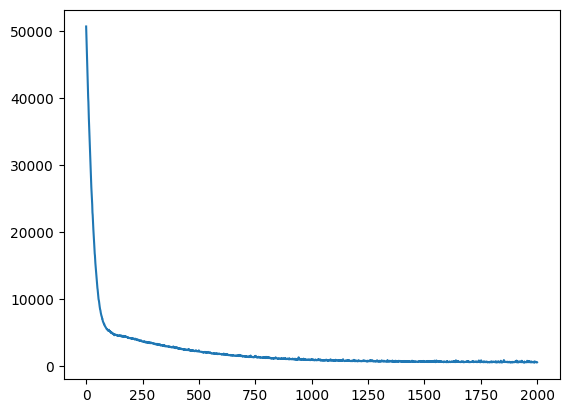

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.plot(losses_);

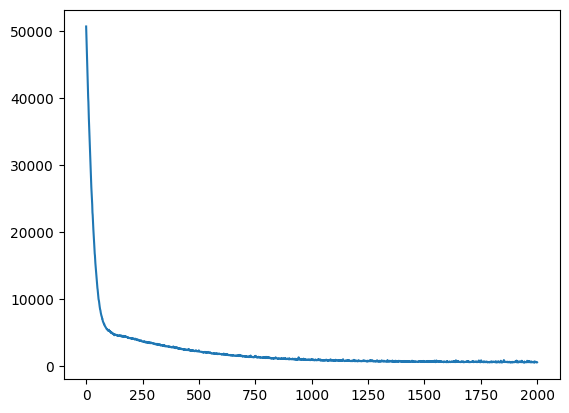

/tmp/ipykernel_7475/3350877026.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_rows] = model_(X_train.unsqueeze(1))[:, -1]
/tmp/ipykernel_7475/3350877026.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_rows+lookback:len(data)] = model_(X_test.unsqueeze(1))[:, -1]


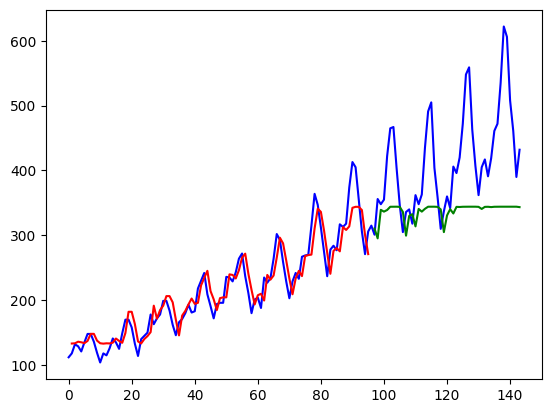

In [21]:
def plot_predicts():
  with torch.no_grad():
      # Зсув прогнозів для тренувальних даних
      train_plot = np.ones_like(data) * np.nan
      y_pred = model_(X_train.unsqueeze(1))
      y_pred = y_pred[:, -1]
      train_plot[lookback:train_rows] = model_(X_train.unsqueeze(1))[:, -1]

      # Зсув прогнозів для тестових даних
      test_plot = np.ones_like(data) * np.nan
      test_plot[train_rows+lookback:len(data)] = model_(X_test.unsqueeze(1))[:, -1]

  # Візуалізація результатів
  plt.plot(data, c='b')  # Реальні дані
  plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
  plt.plot(test_plot, c='g')   # Прогнози на тестових даних
  plt.show()

plot_predicts()

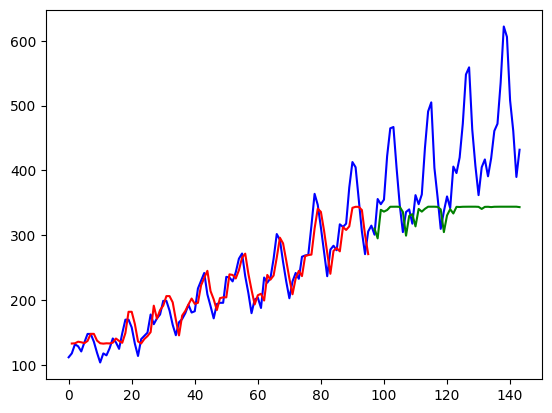

З підвищенням hidden_size до 100 при навчанні моделі помилки на тренувальних даних зменшується в порівнянні з hidden_size = 50 де на візуалізаціях передбачення представляли собою пряму лінію. на тестувальних даних помилка також зменшується але залишається значно вищою ніж була на тренувальних даних що є ознакою перенавчання, а також малим lookback == 1.
 Передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, є низьким значенням, якщо модель буде бачити більше даних то можливо краще навчится.